# 架構 B — LangGraph 外殼 + Claude Code 協調者黑箱

這是「部門開發自動化」架構比較(見 `notebooks/arch/README.md`)裡的選項 B：LangGraph 圖的
節點數量看起來跟架構 H 幾乎一樣少，但背後的意思完全不同——**這裡的平行化真的有在發生，
只是整包塞進 `code_agent` 這一個節點裡，對 LangGraph 完全不透明**。

具體做法：`code_agent` 這一個節點對外只是「呼叫一次 Claude Agent SDK」，但這次呼叫的對象
是一個「協調者」session，讓它自己用 Task 工具、帶 `isolation: "worktree"` 在內部生出 N 個
平行的 implementer、自己判斷要不要合併、要不要重試，最後才把整批結果回傳給 LangGraph。
分波、合併、衝突處理、收斂判斷——這些架構 A 裡明確寫成 `plan_waves`/`merge_wave`/
`resolve_conflict`/`advance_or_finish` 的節點，在這裡全部消失了，不是因為不需要，而是因為
**它們還是存在，只是被搬進了那個協調者 agent 自己的內部決策裡，LangGraph 看不到**。

## 人工介入次數（每個 change）：**2 次，但中途可見度明顯較低**

跟架構 A、H 一樣是對齊一次、驗收一次——這個數字沒有變。但「2 次」這個數字本身會製造誤導：
它暗示「這三個架構在體驗上一樣」，實際上不一樣的是**這兩次核准之間發生了什麼事，你看不看
得到**。架構 A 你能在 LangSmith 或 state 裡逐波看到「哪個 slice 做完了、哪個卡住重試第幾
輪」；架構 B 你只會看到「code_agent 這個節點跑了很久，然後回來了」，中間發生什麼事全部
埋在那次 SDK 呼叫的內部對話紀錄裡。

## 這是研究過程中反覆確認過的取捨，不是猜測

- 這裡分兩件事講清楚,不要混在一起：**已經直接確認過**的是「Claude Code 有一個真的 git
  worktree 機制」——這是從自己手上的工具定義（Agent 工具的 `isolation: "worktree"` 參數）
  跟本機 `claude --help` 都能直接看到（`-w`/`--worktree`、`--tmux` 依賴 `--worktree`）獨立
  對上的，不是聽哪個來源轉述。**還沒有直接確認過**的是：透過 Claude Agent SDK driving 的
  headless coordinator session，內部用 Task 工具生出的 subagent，是不是也能一樣拿到
  `isolation: "worktree"` 這個參數——這個更具體的說法，來源是先前一次背景調查 agent 的回報，
  那次回報裡混了一些疑似不準確的細節（例如講到某個特定版本代號），沒有另外找到獨立來源
  交叉驗證。**這份 sketch 先假設它成立來畫這張圖**，但正式評估架構 B 之前，這一點值得
  實際跑一次驗證，不要只憑文件轉述就下決定。
- 但「什麼時候該放棄重試、交還給人」這個判斷，一旦搬進協調者自己的內部邏輯，就變成那個
  agent 自己的（LLM 驅動的）判斷，不再是像架構 A 的 `review_gate`/`advance_or_finish` 那樣
  的確定性 Python 布林邏輯——這正是整個研究過程中反覆強調「不能讓 LLM 自己決定還要不要
  再試」這條原則會被打破的地方。
- 排查錯誤也變難：架構 A 出事時你看的是哪個 LangGraph 節點的 state，架構 B 出事時你得去挖
  那一次協調者 session 完整的對話紀錄，才能搞清楚它內部到底試了什麼、為什麼放棄。

> 不需要 API key，`code_agent` 這裡是純 Python 假邏輯（回傳一句固定文字），用來示意
> 「LangGraph 只看到一個節點」這件事本身，不是要示範協調者內部真的怎麼運作——那部分本來
> 就不在 LangGraph 看得到的範圍內，這正是這個架構的重點。

In [1]:
import sys
from typing import Literal, TypedDict

sys.path.insert(0, "..")  # 這份 notebook 在 notebooks/arch/ 底下，_graph_viz.py 在上一層
from langchain_core.runnables import RunnableConfig
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.config import get_store
from langgraph.graph import END, START, StateGraph
from langgraph.store.memory import InMemoryStore
from langgraph.types import Command, interrupt

from _graph_viz import show_graph

In [2]:
class DevWorkflowState(TypedDict):
    requirement: str
    code_changes: str
    test_report: str
    review_report: str

## 節點

跟架構 H 節點數一樣少，但 `code_agent` 的職責完全不同——這裡故意把它的 docstring 寫清楚，
提醒自己「這一個節點背後其實跑了一整套多 agent 平行邏輯，只是看不見」。

In [3]:
def align_requirements(state: DevWorkflowState, config: RunnableConfig) -> dict:
    store = get_store()
    thread_id = config["configurable"]["thread_id"]
    feedback = store.get(("workflow", thread_id), "last_feedback")

    requirement = state.get("requirement") or "（示意）需求描述"
    if feedback:
        requirement += f"（依上一輪回饋調整：{feedback.value['reason']}）"

    return {"requirement": requirement}


def code_agent(state: DevWorkflowState) -> dict:
    # 實務上這裡假設是一次 Claude Agent SDK 呼叫，對象是一個協調者 session：
    #   - 協調者自己讀需求、自己決定怎麼拆平行工作
    #   - 用 Task 工具、isolation="worktree" 生出 N 個平行 implementer（worktree 機制本身
    #     已經直接確認存在；「SDK headless session 的 Task 工具也吃得到這個參數」這一點
    #     還沒有獨立驗證過，正式做之前建議先實測，見上面 markdown 的說明）
    #   - 自己判斷要不要合併、合併衝突要不要重試、重試幾次後放棄
    # LangGraph 這一格看到的只有「呼叫開始」跟「呼叫結束、拿到最終結果」，中間的分波/合併/
    # 收斂決策全部發生在協調者自己的對話 session 裡，這裡刻意示意成一個黑盒單一節點。
    return {"code_changes": f"{state['requirement']} 已完成（示意：協調者黑箱，內部細節不可見）"}


def test_agent(state: DevWorkflowState) -> dict:
    return {"test_report": "PASS（示意）"}


def review_agent(state: DevWorkflowState) -> dict:
    return {"review_report": "PASS（示意）"}


def human_checkpoint(
    state: DevWorkflowState, config: RunnableConfig
) -> Command[Literal["align_requirements", "push_or_mr"]]:
    store = get_store()
    thread_id = config["configurable"]["thread_id"]

    decision = interrupt(
        {
            "code_changes": state["code_changes"],
            "test_report": state["test_report"],
            "review_report": state["review_report"],
            "ask": "方向對嗎？resume 一個 dict：{'approve': True} 或 {'approve': False, 'reason': ...}",
        }
    )

    if decision.get("approve"):
        return Command(goto="push_or_mr")

    store.put(("workflow", thread_id), "last_feedback", {"reason": decision.get("reason", "")})
    return Command(goto="align_requirements")


def push_or_mr(state: DevWorkflowState) -> dict:
    return {}

## 組圖

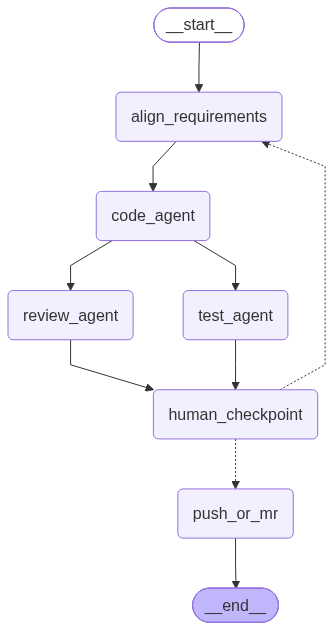

In [4]:
builder = StateGraph(DevWorkflowState)
builder.add_node("align_requirements", align_requirements)
builder.add_node("code_agent", code_agent)
builder.add_node("test_agent", test_agent)
builder.add_node("review_agent", review_agent)
builder.add_node("human_checkpoint", human_checkpoint)
builder.add_node("push_or_mr", push_or_mr)

builder.add_edge(START, "align_requirements")
builder.add_edge("align_requirements", "code_agent")
builder.add_edge("code_agent", "test_agent")
builder.add_edge("code_agent", "review_agent")
builder.add_edge("test_agent", "human_checkpoint")
builder.add_edge("review_agent", "human_checkpoint")
builder.add_edge("push_or_mr", END)

graph = builder.compile(checkpointer=InMemorySaver(), store=InMemoryStore())
show_graph(graph)

## 跑一輪

圖形結構、迴圈行為(核准/打回去)在展示層面跟架構 H 幾乎一樣——這正是重點：**光看這張圖、
光看這次執行的 log，你分不出來這是架構 H 還是架構 B**。差異只存在於 `code_agent` 內部到底
是「真的什麼都沒做的空殼」還是「一次觸發了一整套黑盒多 agent 平行作業」，而這件事在
LangGraph 這一層完全看不出來——這正是這個架構最大的風險：**它在可觀測性上會偽裝成架構 H
的簡單，卻背著架構 A 的複雜度跟成本，但複雜度轉嫁給了你看不到的地方。**

In [5]:
config = {"configurable": {"thread_id": "demo-1"}}

state = graph.invoke({"requirement": "", "code_changes": ""}, config)
print("第一次卡在 human_checkpoint：", state["__interrupt__"][0].value)

state = graph.invoke(Command(resume={"approve": False, "reason": "review 覺得沒處理邊界情況"}), config)
print("\n打回去重對齊之後，需求變成：", state["requirement"])
print("再次卡在 human_checkpoint：", state["__interrupt__"][0].value)

final_state = graph.invoke(Command(resume={"approve": True}), config)
print("\n核准後跑到底，沒有 __interrupt__ 了:", "__interrupt__" not in final_state)

第一次卡在 human_checkpoint： {'code_changes': '（示意）需求描述 已完成（示意：協調者黑箱，內部細節不可見）', 'test_report': 'PASS（示意）', 'review_report': 'PASS（示意）', 'ask': "方向對嗎？resume 一個 dict：{'approve': True} 或 {'approve': False, 'reason': ...}"}

打回去重對齊之後，需求變成： （示意）需求描述（依上一輪回饋調整：review 覺得沒處理邊界情況）
再次卡在 human_checkpoint： {'code_changes': '（示意）需求描述（依上一輪回饋調整：review 覺得沒處理邊界情況） 已完成（示意：協調者黑箱，內部細節不可見）', 'test_report': 'PASS（示意）', 'review_report': 'PASS（示意）', 'ask': "方向對嗎？resume 一個 dict：{'approve': True} 或 {'approve': False, 'reason': ...}"}

核准後跑到底，沒有 __interrupt__ 了: True


## 跟架構 A 的差異一覽（不是跟架構 H 比——H 是「真的簡單」，B 是「看起來簡單」）

| | 架構 B（這份） | 架構 A |
|---|---|---|
| LangGraph 節點數 | 6 | 12 |
| 平行化 | 有，但在 `code_agent` 內部、LangGraph 看不到 | 有，`Send`/wave 在 LangGraph state 裡明確可見 |
| 合併/收斂判斷 | 協調者 agent 自己的（LLM 驅動）判斷 | `merge_wave`/`review_gate`/`advance_or_finish` 的確定性 Python 判斷 |
| 排查一次卡住的 run | 要挖協調者 session 的完整對話紀錄 | 直接看 LangGraph state／LangSmith trace |
| 實作/維護成本（LangGraph 這一側） | 低（幾乎沒有邏輯要寫） | 高（wave/merge/resolve 邏輯都要自己維護） |
| 人工介入次數 | 2 | 2 |

**什麼情況下 B 反而是合理選擇**：如果部門評估後認為「協調者黑箱」的不透明可以接受（例如
change 都很小、很少真的需要平行、出錯了直接整個重跑成本也不高），B 用最少的 LangGraph 程式
碼換到跟 A 一樣的「兩次人工介入」體驗，開發成本低很多。但如果部門在意的是「出錯了要能講清楚
哪裡卡住、為什麼卡住」，這個架構會在關鍵時刻讓人最頭痛——複雜度沒有消失，只是換了個看不到
的地方。